In [1]:
import pandas as pd
import os
from pymatgen.io.vasp.outputs import Vasprun
task = Vasprun(filename="./Si_eos/v0/vasprun.xml")
print(task.final_structure.volume)

160.16581804914694


In [2]:
vasprun = Vasprun('./Si_eos/v0/band/vasprun.xml')
band_gap = vasprun.get_band_structure().get_band_gap()
print(band_gap)

{'direct': False, 'energy': 0.6749999999999998, 'transition': 'GAMMA-(0.020,0.020,0.039)'}


In [3]:
print(band_gap['energy'])

0.6749999999999998


In [4]:
dirlist=next(os.walk('./Si_eos'))[1]
print(dirlist)

['v0', 'v1', 'v2', 'v3', 'v4', 'v5', 'vn1', 'vn2', 'vn3', 'vn4', 'vn5']


In [5]:
volume=[]
bandgap = []
for i in range(len(dirlist)):
    path0="./Si_eos/"+dirlist[i]
    task= Vasprun(filename=path0+"/vasprun.xml")
    volume.append(task.final_structure.volume)
    
    path="./Si_eos/"+dirlist[i]+"/band"
    vasprun = Vasprun(path+"/vasprun.xml")
    band_gap = vasprun.get_band_structure().get_band_gap()
    bandgap.append(band_gap['energy'])
print(volume)
print(bandgap)

[160.16581804914694, 165.01900250185415, 169.9692474402991, 175.01751385939016, 180.16476275403562, 185.4119551191437, 155.40873308726924, 150.74678662131265, 146.17901765636904, 141.70446519753, 137.3221682498873]
[0.6749999999999998, 0.7306999999999997, 0.7792000000000003, 0.8288000000000002, 0.8719000000000001, 0.9085000000000001, 0.6119000000000003, 0.5473999999999997, 0.47940000000000005, 0.4068000000000005, 0.3271999999999995]


In [6]:
gap_dict= {dirlist[i]:[volume[i],bandgap[i]] for i in range(len(dirlist))}
print(gap_dict)

{'v0': [160.16581804914694, 0.6749999999999998], 'v1': [165.01900250185415, 0.7306999999999997], 'v2': [169.9692474402991, 0.7792000000000003], 'v3': [175.01751385939016, 0.8288000000000002], 'v4': [180.16476275403562, 0.8719000000000001], 'v5': [185.4119551191437, 0.9085000000000001], 'vn1': [155.40873308726924, 0.6119000000000003], 'vn2': [150.74678662131265, 0.5473999999999997], 'vn3': [146.17901765636904, 0.47940000000000005], 'vn4': [141.70446519753, 0.4068000000000005], 'vn5': [137.3221682498873, 0.3271999999999995]}


In [7]:
df = pd.DataFrame.from_dict(gap_dict,orient="index")
df.columns=['volume','bandgap']
df

,volume,bandgap
v0,160.165818,0.6750
v1,165.019003,0.7307
v2,169.969247,0.7792
v3,175.017514,0.8288
v4,180.164763,0.8719
v5,185.411955,0.9085
vn1,155.408733,0.6119
vn2,150.746787,0.5474
vn3,146.179018,0.4794
vn4,141.704465,0.4068


In [8]:
df_order=df.sort_values(by=['volume'],ascending=[False])
print(df_order)

         volume  bandgap
v5   185.411955   0.9085
v4   180.164763   0.8719
v3   175.017514   0.8288
v2   169.969247   0.7792
v1   165.019003   0.7307
v0   160.165818   0.6750
vn1  155.408733   0.6119
vn2  150.746787   0.5474
vn3  146.179018   0.4794
vn4  141.704465   0.4068
vn5  137.322168   0.3272


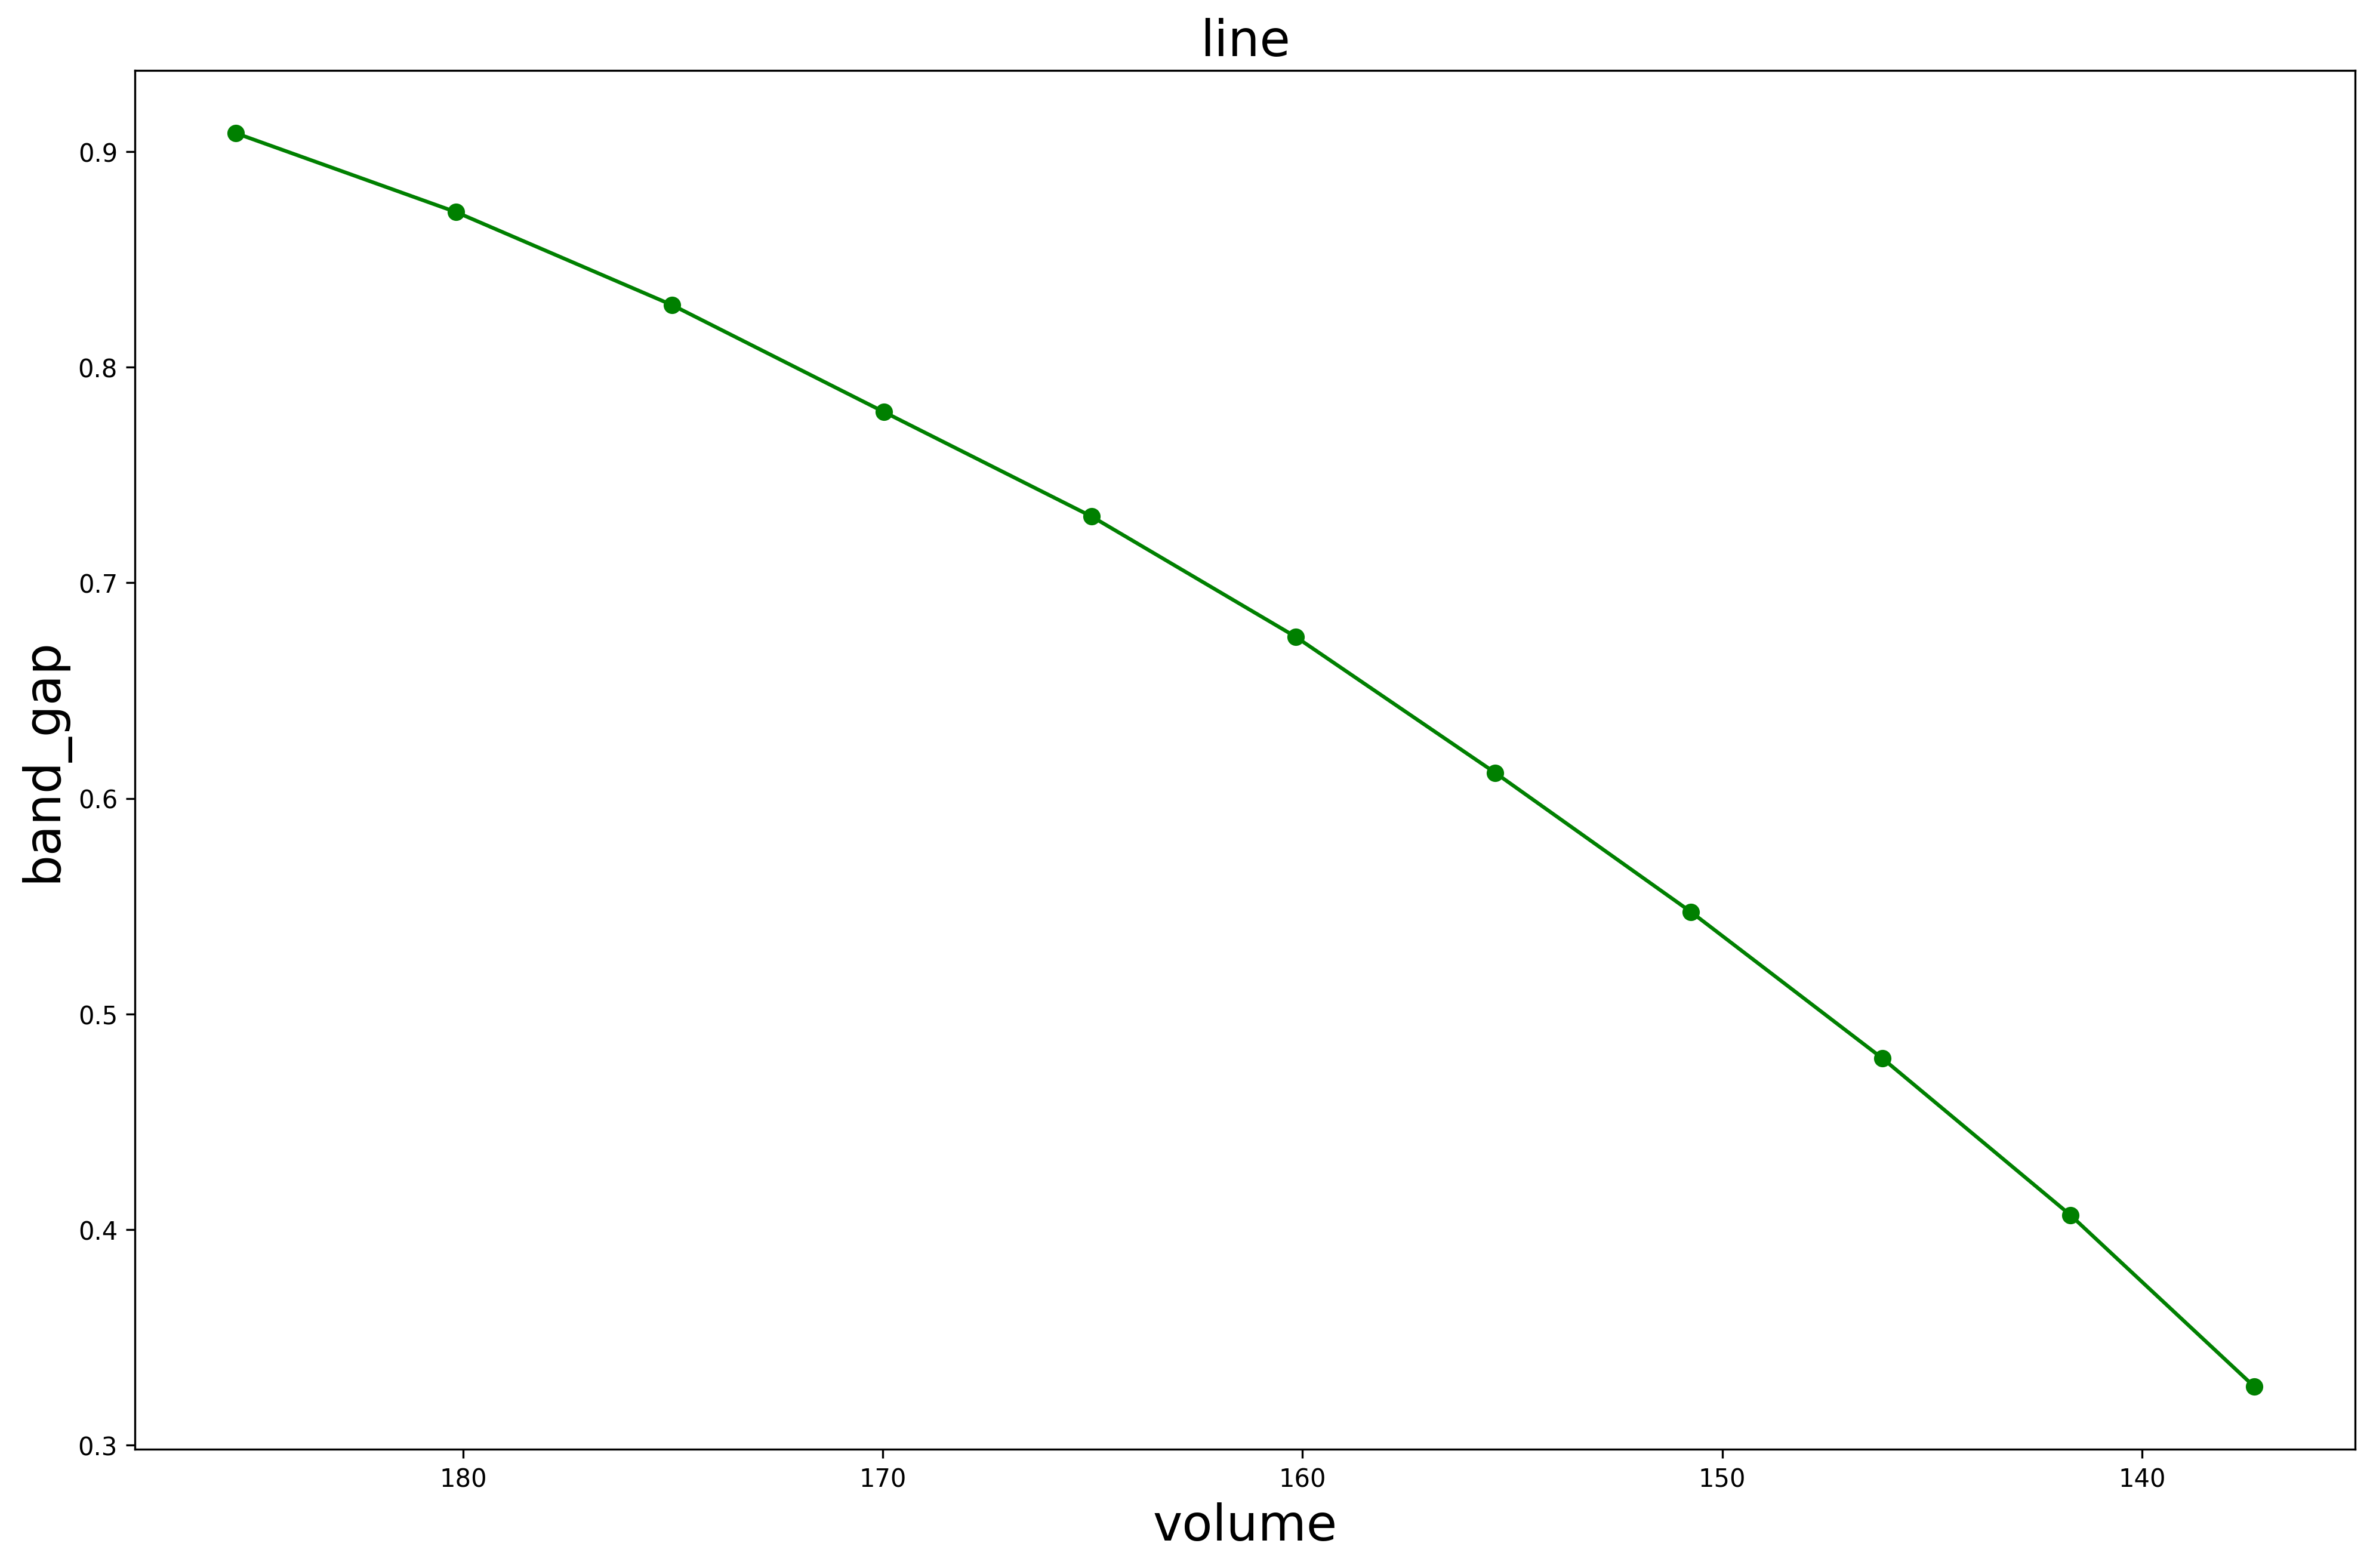

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 10), dpi=300)
x=df_order['volume']
y=df_order['bandgap']
plt.plot(x, y, c='g', marker='o')
plt.gca().invert_xaxis()
plt.axis('tight')
plt.title("line",fontsize=20)
plt.xlabel("volume",fontsize=20)
plt.ylabel("band_gap",fontsize=20)
plt.show()